# Lab Day 1 — Notebook (Forest CoverType, MLP) — MSSV 2A202602985

Notebook đã hoàn thiện và chạy từ đầu đến cuối (Restart & Run All) không lỗi; output giữ nguyên. Cấu trúc: Part 0 (dữ liệu) → Part 1 (model và kiểm tra ban đầu) → Part 2 (pipeline và baseline, 5 seed) → Part 3 (7 chủ đề thí nghiệm) → Part 4 (đánh giá eval, bảng, nộp bài). Báo cáo: `../REPORT.md`.

**Cách chạy**
1. Từ thư mục gốc repo: `mkdir -p submission_<MSSV> && cp -r code submission_<MSSV>/code` (bản này đã nằm ở `submission_2A202602985/code/`).
2. Mở notebook với thư mục làm việc là `submission_2A202602985/code/` (nên `REPO_ROOT = "../.."` và `OUT_DIR = ".."` đúng; ảnh/kết quả ghi vào `../figures`, `../results`).
3. Colab: đặt repo trên Drive và dùng nhánh `IN_COLAB` ở ô cấu hình (đường dẫn tuyệt đối); máy Mac Apple Silicon dùng `mps` tự động. Cả notebook mất khoảng 20–25 phút trên GPU của MacBook Air.


In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:   # Colab: repo + bài nộp nằm trên Drive (xem hướng dẫn trong báo cáo); đường dẫn tuyệt đối
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_ROOT = "/content/drive/MyDrive/lab1/K4-Track4-Day1-Neuralnetwork"
    OUT_DIR   = f"{REPO_ROOT}/submission_2A202602985"
    os.chdir(f"{OUT_DIR}/code")
else:          # chạy tại submission_<MSSV>/code/: REPO_ROOT trỏ về gốc repo, OUT_DIR về thư mục nộp
    REPO_ROOT = "../.."
    OUT_DIR   = ".."
sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd(), "| REPO_ROOT:", REPO_ROOT, "| OUT_DIR:", OUT_DIR)

# Chọn device: "cuda" nếu có GPU NVIDIA, "mps" nếu là Mac (Apple Silicon), ngược lại "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("PyTorch", torch.__version__, "| device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
elif device == "mps":
    print("GPU: Apple Silicon (MPS)")
for sub in ("figures", "results"):
    os.makedirs(f"{OUT_DIR}/{sub}", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval, score_predictions
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

cwd: /Users/chung140204/K4-Track4-Day1-Neuralnetwork/submission_2A202602985/code | REPO_ROOT: ../.. | OUT_DIR: ..
PyTorch 2.8.0 | device: mps
GPU: Apple Silicon (MPS)


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# 1) Chia train/eval theo metadata (tạo data/processed/train.npz, eval.npz)
subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

# 2) Tách val (20%, phân tầng, seed 42), chuẩn hoá bằng thống kê của train, đưa lên device
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

# 3) Kích thước, kiểu dữ liệu, khoảng nhãn
for k in ("X_tr", "y_tr", "X_val", "y_val", "X_eval", "y_eval"):
    print(f"{k:7s} {tuple(data[k].shape)}  {data[k].dtype}  {data[k].device}")
print("eval_row_id:", data["eval_row_id"].shape, data["eval_row_id"].dtype,
      "| tăng dần:", bool((data["eval_row_id"][1:] > data["eval_row_id"][:-1]).all()))
assert data["X_tr"].shape == (371_847, 54) and data["X_val"].shape == (92_962, 54) and data["X_eval"].shape == (116_203, 54)
assert data["y_tr"].min() >= 0 and data["y_tr"].max() <= 6

# 4) Chuẩn hoá: 10 cột số trên X_tr phải ≈ 0 / 1; 44 cột nhị phân giữ nguyên {0, 1}
num = data["X_tr"][:, :10]
print("mean (10 cột số):", num.mean(0).cpu().numpy().round(4))
print("std  (10 cột số):", num.std(0).cpu().numpy().round(4))
assert num.mean(0).abs().max() < 1e-3 and (num.std(0) - 1).abs().max() < 1e-3
assert set(data["X_tr"][:, 10:].unique().cpu().tolist()) <= {0.0, 1.0}
print("val/eval dùng mean/std của train nên mean/std của chúng chỉ xấp xỉ 0/1:",
      data["X_val"][:, :10].mean(0).abs().max().item() < 0.05)


train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876


train (371847, 54) | val (92962, 54) | eval (116203, 54)
luôn đoán lớp đa số (lớp 1) -> accuracy val = 0.4876
X_tr    (371847, 54)  torch.float32  mps:0
y_tr    (371847,)  torch.int64  mps:0
X_val   (92962, 54)  torch.float32  mps:0
y_val   (92962,)  torch.int64  mps:0
X_eval  (116203, 54)  torch.float32  mps:0
y_eval  (116203,)  torch.int64  mps:0
eval_row_id: (116203,) int64 | tăng dần: True
mean (10 cột số): [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  (10 cột số): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
val/eval dùng mean/std của train nên mean/std của chúng chỉ xấp xỉ 0/1: True


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879
Linear   -> (8, 256)
ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)


loss bước 0 trên val = 2.3776 | ln 7 = 1.9459


quá khớp 20 mẫu: loss đầu = 2.6738 -> cuối = 0.000006 | accuracy = 1.00


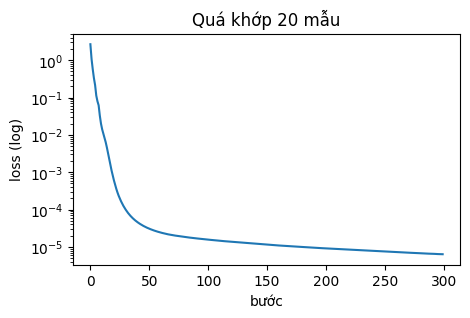

net.0.weight shape (256, 54)    grad norm = 0.58230
net.0.bias   shape (256,)       grad norm = 0.38331
net.2.weight shape (128, 256)   grad norm = 2.37169
net.2.bias   shape (128,)       grad norm = 0.49814
net.4.weight shape (7, 128)     grad norm = 2.07833
net.4.bias   shape (7,)         grad norm = 0.60607


In [3]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(42)

# 1) Dựng M-base (He init) và kiểm tra số tham số
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
print(model)
print("số tham số:", count_params(model))
assert count_params(model) == EXPECTED_PARAMS[(256, 128)]

# 2) Một lô ngẫu nhiên (8, 54): in shape sau từng lớp, kiểm tra logits (8, 7)
h = torch.randn(8, 54, device=device)
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:8s} -> {tuple(h.shape)}")
assert h.shape == (8, 7)

# 3) Loss bước 0 trên val (eval mode): kỳ vọng ≈ ln 7 ≈ 1.946
model.eval()
with torch.no_grad():
    loss0 = F.cross_entropy(model(data["X_val"]), data["y_val"]).item()
print(f"loss bước 0 trên val = {loss0:.4f} | ln 7 = {np.log(7):.4f}")

# 4) Quá khớp 20 mẫu (tắt dropout): loss phải về gần 0, accuracy 100%
m20 = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
x20, y20 = data["X_tr"][:20], data["y_tr"][:20]
opt20 = torch.optim.Adam(m20.parameters(), lr=1e-2)
m20.train()
curve = []
for step in range(300):
    opt20.zero_grad()
    loss = F.cross_entropy(m20(x20), y20)
    loss.backward()
    opt20.step()
    curve.append(loss.item())
m20.eval()
with torch.no_grad():
    acc20 = (m20(x20).argmax(1) == y20).float().mean().item()
print(f"quá khớp 20 mẫu: loss đầu = {curve[0]:.4f} -> cuối = {curve[-1]:.6f} | accuracy = {acc20:.2f}")
assert curve[-1] < 0.01 and acc20 == 1.0
plt.figure(figsize=(5, 3)); plt.plot(curve)
plt.yscale("log"); plt.xlabel("bước"); plt.ylabel("loss (log)"); plt.title("Quá khớp 20 mẫu")
plt.savefig(f"{OUT_DIR}/figures/overfit20.png", dpi=150, bbox_inches="tight"); plt.show()

# 5) Gradient có chảy không? Sau một lần backward, in chuẩn gradient từng tham số
model.train()
model.zero_grad()
F.cross_entropy(model(data["X_tr"][:512]), data["y_tr"][:512]).backward()
for name, p in model.named_parameters():
    assert p.grad is not None, f"{name} không có gradient"
    gn = p.grad.norm().item()
    print(f"{name:12s} shape {tuple(p.shape)!s:12s} grad norm = {gn:.5f}")
    assert gn > 0, f"{name} có gradient bằng 0"


**Nhận xét Part 1:** loss bước 0 trên val đo được = 2,378, so với ln 7 = 1,946 thì cao hơn khoảng 0,43. Nguyên nhân: khởi tạo He (Var = 2/n_in) làm logits lớp cuối có std ≈ 0,55–0,6 (đo thêm trên 5 seed khác, loss bước 0 nằm trong khoảng 1,90–2,31), nên softmax không còn đều và loss lớn hơn ln 7; gain √2 của He dành cho lớp có ReLU phía sau, trong khi lớp cuối không có ReLU nên logits hơi lớn. Độ lệch ở mức vừa phải và đầu vào đã chuẩn hoá (Part 0), nên không có dấu hiệu lỗi chuẩn hoá hay độ lớn điểm số bất thường.

Quá khớp 20 mẫu: loss giảm từ 2,67 xuống 6e-6, accuracy 100% sau 300 bước (Adam, lr = 1e-2, dropout tắt), cho thấy model và vòng cập nhật (zero_grad → backward → step) phối hợp đúng; đây mới là kiểm tra khả năng khớp một lô nhỏ, chưa phải bằng chứng tổng quát hoá. Gradient: sau một lần backward, cả 6 tham số (3 weight, 3 bias) đều khác None và khác 0 (grad norm từ 0,38 đến 2,37), nên không có tham số nào bị bỏ qua.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

Quy ước dùng cho mọi thí nghiệm: cùng phép tách val, cùng 20 epoch, cùng `seed=1` (trừ khi đang đo nhiễu seed), mỗi lần chỉ đổi **một** yếu tố so với baseline (hoặc ghi rõ trong `notes`). `train_loss` đo ở `eval()` trên 50 000 mẫu train cố định; `grad_norm` đo **trước** khi clip; epoch tốt nhất chọn theo val loss.

In [4]:
R = {}      # exp_id -> result (giữ trong RAM; best_state của từng lần chạy dùng ở Part 4)
EVAL = {}   # exp_id -> điểm eval (CHỈ baseline và cấu hình cuối cùng, điền ở Part 4)
NOISE = {}  # độ nhiễu seed của baseline (điền sau khi chạy nhiều seed)

def log_result(res):
    """Lưu JSON + ảnh riêng figures/<exp_id>.png, đăng ký vào R, in một dòng tóm tắt."""
    c, s = res["cfg"], res["summary"]
    save_result(res, f"{OUT_DIR}/results")
    plot_run(res, f"{OUT_DIR}/figures/{c['exp_id']}.png")
    R[c["exp_id"]] = res
    line = (f"{c['exp_id']:26s} step0={s['step0_loss']:.3f} | best val loss={s['best_val_loss']:.4f}@{s['best_epoch']:>2} | "
            f"val acc={s['val_acc']:.4f} macro-F1={s['val_macro_f1']:.4f} | {s['time_per_epoch_s']:.2f}s/epoch")
    if s["diverged"]:
        line += " | DIVERGED"
    if NOISE and c["group"] != "baseline":
        d = s["val_macro_f1"] - NOISE["mean"]
        line += f" | Δ macro-F1 vs baseline = {d:+.4f} ({'VƯỢT' if abs(d) > 2 * NOISE['std'] else 'không vượt'} 2σ={2 * NOISE['std']:.4f})"
    print(line)

**Tìm `lr` cho baseline bằng val.** Quét SGD+momentum với lr cách nhau ~3 lần (0.01 → 1.0), một seed, chọn lr có `val_macro_f1` cao nhất tại epoch tốt nhất. Lưới được xác định sau một lần quét thăm dò trên val (không dùng eval). Lần chạy có lr được chọn chính là `base-s1`; các lần còn lại được giữ làm thí nghiệm hyper-parameter (`hp-lr-sgdm-*`).

In [5]:
LR_GRID = [0.01, 0.03, 0.1, 0.3, 1.0]
sweep = {}
for lr in LR_GRID:
    sweep[lr] = run_experiment({**DEFAULT_CFG, "lr": lr, "seed": 1, "exp_id": f"hp-lr-sgdm-{lr:g}", "group": "hparam",
                                "description": f"SGD+momentum, lr={lr:g} (quét lr cho baseline)"}, data)

print(f"{'lr':>6s} {'best val loss':>14s} {'val acc':>8s} {'val macro-F1':>13s}  diverged")
for lr in LR_GRID:
    s = sweep[lr]["summary"]
    print(f"{lr:>6g} {s['best_val_loss']:>14.4f} {s['val_acc']:>8.4f} {s['val_macro_f1']:>13.4f}  {s['diverged']}")

best_lr = max(LR_GRID, key=lambda lr: sweep[lr]["summary"]["val_macro_f1"])   # chọn bằng val
print("lr được chọn cho baseline:", best_lr)
BASE_CFG = {**DEFAULT_CFG, "lr": best_lr}

base1 = sweep.pop(best_lr)
base1["cfg"].update(exp_id="base-s1", group="baseline", description=f"Baseline M-base, seed 1 (lr={best_lr:g} chọn bằng val)")
log_result(base1)
for res in sweep.values():
    log_result(res)

    lr  best val loss  val acc  val macro-F1  diverged
  0.01         0.3201   0.8708        0.7658  False
  0.03         0.2629   0.8943        0.8175  False
   0.1         0.2321   0.9067        0.8511  False
   0.3         0.2234   0.9113        0.8551  False
     1         1.2057   0.4876        0.0936  False
lr được chọn cho baseline: 0.3


base-s1                    step0=2.269 | best val loss=0.2234@20 | val acc=0.9113 macro-F1=0.8551 | 0.88s/epoch
hp-lr-sgdm-0.01            step0=2.269 | best val loss=0.3201@19 | val acc=0.8708 macro-F1=0.7658 | 0.93s/epoch


hp-lr-sgdm-0.03            step0=2.269 | best val loss=0.2629@18 | val acc=0.8943 macro-F1=0.8175 | 0.78s/epoch
hp-lr-sgdm-0.1             step0=2.269 | best val loss=0.2321@18 | val acc=0.9067 macro-F1=0.8511 | 0.88s/epoch


hp-lr-sgdm-1               step0=2.269 | best val loss=1.2057@ 8 | val acc=0.4876 macro-F1=0.0936 | 0.87s/epoch


**Đo nhiễu seed:** chạy baseline với 5 seed (1–5). Nhiễu dùng trong cả bài là σ của `val_macro_f1` giữa các seed; chênh lệch nhỏ hơn 2σ không được coi là bằng chứng.

In [6]:
for s in (2, 3, 4, 5):
    log_result(run_experiment({**BASE_CFG, "seed": s, "exp_id": f"base-s{s}", "description": f"Baseline M-base, seed {s}"}, data))

base_ids = [f"base-s{s}" for s in range(1, 6)]
f1 = np.array([R[i]["summary"]["val_macro_f1"] for i in base_ids])
acc = np.array([R[i]["summary"]["val_acc"] for i in base_ids])
vl = np.array([R[i]["summary"]["best_val_loss"] for i in base_ids])
NOISE.update(mean=float(f1.mean()), std=float(f1.std(ddof=1)))
print(f"\nBaseline qua {len(base_ids)} seed (lr={best_lr:g}):")
print(f"  val macro-F1 : {f1.mean():.4f} ± {f1.std(ddof=1):.4f}   (2σ = {2 * f1.std(ddof=1):.4f})")
print(f"  val accuracy : {acc.mean():.4f} ± {acc.std(ddof=1):.4f}")
print(f"  best val loss: {vl.mean():.4f} ± {vl.std(ddof=1):.4f}")

# hình dạng đường cong của base-s1
h = R["base-s1"]["history"]; s1 = R["base-s1"]["summary"]
print(f"\nbase-s1: loss bước 0 = {s1['step0_loss']:.3f} (ln 7 = {np.log(7):.3f}), best epoch = {s1['best_epoch']}")
print("epoch  train_loss  val_loss  val_acc  val_macro_f1  grad_norm")
for e in (1, 2, 5, 10, 15, 20):
    i = e - 1
    print(f"{e:>5d}  {h['train_loss'][i]:>10.4f}  {h['val_loss'][i]:>8.4f}  {h['val_acc'][i]:>7.4f}  {h['val_macro_f1'][i]:>12.4f}  {h['grad_norm'][i]:>9.3f}")
print(f"val acc cuối = {s1['val_acc']:.4f} so với mốc đoán lớp đa số 0.4876")

base-s2                    step0=1.978 | best val loss=0.2102@19 | val acc=0.9154 macro-F1=0.8583 | 0.92s/epoch


base-s3                    step0=1.901 | best val loss=0.2238@18 | val acc=0.9122 macro-F1=0.8584 | 0.95s/epoch


base-s4                    step0=2.311 | best val loss=0.2291@19 | val acc=0.9092 macro-F1=0.8548 | 0.92s/epoch


base-s5                    step0=2.144 | best val loss=0.2152@20 | val acc=0.9149 macro-F1=0.8618 | 0.92s/epoch

Baseline qua 5 seed (lr=0.3):
  val macro-F1 : 0.8577 ± 0.0029   (2σ = 0.0058)
  val accuracy : 0.9126 ± 0.0026
  best val loss: 0.2203 ± 0.0075

base-s1: loss bước 0 = 2.269 (ln 7 = 1.946), best epoch = 20
epoch  train_loss  val_loss  val_acc  val_macro_f1  grad_norm
    1      0.4382    0.4419   0.8085        0.6848      0.385
    2      0.3769    0.3824   0.8401        0.6941      0.369
    5      0.3136    0.3243   0.8641        0.7679      0.360
   10      0.2471    0.2638   0.8922        0.8297      0.349
   15      0.2344    0.2585   0.8971        0.8270      0.347
   20      0.2004    0.2234   0.9113        0.8551      0.340
val acc cuối = 0.9113 so với mốc đoán lớp đa số 0.4876


**Nhận xét baseline:** lr được chọn bằng val là **0.3** (SGD+momentum 0.9; val macro-F1 theo lr: 0.01→0.766, 0.03→0.818, 0.1→0.851, 0.3→0.855, 1.0→0.094 do sập). Lưu ý 0.1 và 0.3 chỉ cách nhau 0.004 < 2σ, nên lr "tốt nhất" nằm trong một vùng phẳng; mình vẫn dùng quy tắc đã đặt trước (macro-F1 cao nhất). **Hình dạng đường cong** (`base-s1`): train loss và val loss giảm đều từ 0.44 xuống 0.20 / 0.22; khoảng cách val − train chỉ 0.023 và **best epoch = 20 (hoặc 18–20 ở các seed)**, tức mô hình chưa quá khớp mà vẫn đang học khi dừng ở epoch 20 (hơi chưa khớp / chưa hội tụ). Val macro-F1 dao động theo epoch (0.830 ở epoch 10, 0.827 ở epoch 15, 0.855 ở epoch 20) vì các lớp hiếm (lớp 3 chỉ 0.5%) nhạy với từng cập nhật, trong khi val loss giảm đều hơn. **So với mốc đoán đa số:** val accuracy 0.9113 so với 0.4876 (macro-F1 0.855 so với 0.094). **Độ nhiễu seed (5 seed):** val macro-F1 = 0.8577 ± 0.0029 nên **ngưỡng nhiễu 2σ = 0.0058**; val accuracy 0.9126 ± 0.0026. `grad_norm` trung bình theo epoch ổn định ở 0.34–0.39 nhưng bước lớn nhất đạt 2.95 (≈ 8 lần trung vị), có "gai" gradient.

In [7]:
# Helper dùng chung cho Part 3: đổi MỘT yếu tố so với BASE_CFG, chạy, lưu ảnh + JSON.
def run_exp(exp_id, group, description, notes="", **override):
    res = run_experiment({**BASE_CFG, **override, "exp_id": exp_id, "group": group,
                          "description": description, "notes": notes}, data)
    log_result(res)
    return res

def compare(ids, metric, name, title):
    plot_compare([R[i] for i in ids], metric, f"{OUT_DIR}/figures/{name}.png", title)

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Mọi so sánh dùng **val**; ngưỡng nhiễu là 2σ của baseline (5 seed). Cả 7 chủ đề đều được thử: loss · optimizer · hparam · dropout · clipping · amp · init.

### Chủ đề 1 — Hàm mất mát: CE vs MSE (`loss-*`)
**Dự đoán trước (viết TRƯỚC khi chạy):** MSE trên one-hot hội tụ chậm hơn và cho macro-F1 thấp hơn CE ở cùng lr. Gradient của CE theo logit là `p − y` (không bão hoà khi dự đoán sai nặng), còn MSE (trung bình trên 7 phần tử, không có hệ số ½) có gradient `2(z − y)/7` nhỏ hơn khoảng 3,5 lần và không "kéo mạnh" khi sai nặng. Với lr lớn hơn ~3 lần MSE sẽ tiến gần CE hơn nhưng không vượt CE quá nhiễu seed. **Không so loss CE và MSE trực tiếp** (khác thang đo); so accuracy, macro-F1 và tốc độ hội tụ.

In [8]:
run_exp(f"loss-mse-lr{best_lr:g}", "loss", f"MSE trên one-hot, cùng lr={best_lr:g} với baseline", loss="mse",
        notes="MSE = F.mse_loss(logit, one-hot) trung bình trên B x 7 phần tử, không hệ số 1/2; loss khác thang với CE nên không so trực tiếp.")
run_exp("loss-mse-lr1", "loss", "MSE, lr=1.0 (≈ ×3.3 để bù gradient nhỏ hơn)", loss="mse", lr=1.0,
        notes="Đổi cả loss và lr (lr ×3.3) để xem MSE có theo kịp CE khi bù gradient nhỏ hơn không.")
compare(["base-s1", f"loss-mse-lr{best_lr:g}", "loss-mse-lr1"], "val_macro_f1", "compare_loss", "Hàm mất mát: val macro-F1 (CE vs MSE)")
compare(["base-s1", f"loss-mse-lr{best_lr:g}", "loss-mse-lr1"], "grad_norm", "compare_loss_gradnorm", "Hàm mất mát: grad_norm trung bình")
for i in ("base-s1", f"loss-mse-lr{best_lr:g}", "loss-mse-lr1"):
    print(f"{i:20s} grad_norm epoch 1 = {R[i]['history']['grad_norm'][0]:.4f} | epoch 20 = {R[i]['history']['grad_norm'][-1]:.4f}")

loss-mse-lr0.3             step0=0.636 | best val loss=0.0274@18 | val acc=0.8811 macro-F1=0.7818 | 0.90s/epoch | Δ macro-F1 vs baseline = -0.0759 (VƯỢT 2σ=0.0058)


loss-mse-lr1               step0=0.636 | best val loss=0.0338@20 | val acc=0.8552 macro-F1=0.6282 | 0.86s/epoch | Δ macro-F1 vs baseline = -0.2295 (VƯỢT 2σ=0.0058)
base-s1              grad_norm epoch 1 = 0.3852 | epoch 20 = 0.3404
loss-mse-lr0.3       grad_norm epoch 1 = 0.0563 | epoch 20 = 0.0686
loss-mse-lr1         grad_norm epoch 1 = 0.0787 | epoch 20 = 0.0687


**Đối chiếu (loss):** khớp phần lớn dự đoán. MSE kém hơn CE rõ rệt ở cùng lr: `loss-mse-lr0.3` có val macro-F1 **0.782** (−0.076 so với baseline 0.858, gấp ~13 lần ngưỡng 2σ = 0.0058) và accuracy 0.881 so với 0.911 (hình `compare_loss.png`). Cơ chế đo được: `grad_norm` epoch 1 của MSE chỉ **0.056** so với **0.385** của CE (nhỏ hơn ~7 lần, nhiều hơn mức 3.5 lần mình tính vì gradient MSE còn nhân với độ lệch `z − y` của logit chứ không phải xác suất), nên mỗi bước đi nhỏ hơn và MSE hội tụ chậm hơn trong 20 epoch. **Khác dự đoán:** tăng lr lên 1.0 để bù không làm MSE tốt lên mà **tệ hơn** (`loss-mse-lr1`: macro-F1 0.628, accuracy 0.855). Mình chưa kiểm chứng nguyên nhân (giả thuyết: với momentum 0.9, lr 1.0 làm logit tuyến tính dao động mạnh quanh đích one-hot, đặc biệt ở các lớp hiếm), nên chỉ ghi đây là kết quả bất ngờ. Giá trị loss (0.636 → 0.027 với MSE, 2.27 → 0.22 với CE) khác thang đo nên không được so trực tiếp; kết luận chỉ dựa trên accuracy/macro-F1.

### Chủ đề 2 — Bộ tối ưu hoá (`opt-*`)
**Dự đoán trước:** Adam/AdamW (lr khoảng 1e-3–3e-3) đạt val macro-F1 cao hơn SGD+momentum ở lr tốt nhất của mỗi bộ, vì Adam chia bước theo độ lớn gradient từng tham số, phù hợp với đầu vào trộn 10 cột liên tục và 44 cột nhị phân thưa. SGD thường (không momentum) cần lr lớn hơn khoảng 10 lần SGD+momentum 0,9 (bước hiệu dụng `lr/(1−μ)`). AdamW với `weight_decay=0` cho kết quả trùng Adam. Mỗi bộ tối ưu thử ≥ 3 lr cách nhau 3 lần rồi so ở lr tốt nhất. *(Trung thực: lưới lr được đặt sau lần quét thăm dò trên val nên mình đã thấy sơ bộ xếp hạng bộ tối ưu trước khi viết dự đoán này.)*

In [9]:
for lr in (0.3, 1.0, 3.0):
    run_exp(f"opt-sgd-lr{lr:g}", "optimizer", f"SGD thuần (không momentum), lr={lr:g}", optimizer="sgd", lr=lr)
for lr in (3e-4, 1e-3, 3e-3, 1e-2):
    run_exp(f"opt-adam-lr{lr:g}", "optimizer", f"Adam, lr={lr:g}", optimizer="adam", lr=lr,
            notes="betas=(0.9, 0.999), eps=1e-8, weight_decay=0")
for lr in (1e-3, 3e-3):
    run_exp(f"opt-adamw-lr{lr:g}", "optimizer", f"AdamW, lr={lr:g}, weight_decay=0.01", optimizer="adamw", lr=lr, weight_decay=0.01,
            notes="betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01 (tách riêng)")
run_exp("opt-adamw-wd0-lr3e-3", "optimizer", "AdamW với weight_decay=0, lr=3e-3 (kiểm tra trùng Adam lr=3e-3)", optimizer="adamw", lr=3e-3,
        notes="weight_decay=0 nên AdamW phải trùng Adam cùng lr/seed.")

FAMILIES = {
    "SGD":          [f"opt-sgd-lr{lr:g}" for lr in (0.3, 1.0, 3.0)],
    "SGD+momentum": ["base-s1"] + [i for i in R if i.startswith("hp-lr-sgdm-")],
    "Adam":         [f"opt-adam-lr{lr:g}" for lr in (3e-4, 1e-3, 3e-3, 1e-2)],
    "AdamW (wd=0.01)": [f"opt-adamw-lr{lr:g}" for lr in (1e-3, 3e-3)],
}
print("\nTheo bộ tối ưu: lr tốt nhất (chọn theo val macro-F1)")
print(f"{'bộ tối ưu':16s} {'exp_id':22s} {'lr':>7s} {'val macro-F1':>13s} {'val acc':>8s} {'best val loss':>14s} {'best ep':>8s}")
best_of = {}
for fam, ids in FAMILIES.items():
    b = max(ids, key=lambda i: R[i]["summary"]["val_macro_f1"])
    best_of[fam] = b
    s, c = R[b]["summary"], R[b]["cfg"]
    print(f"{fam:16s} {b:22s} {c['lr']:>7g} {s['val_macro_f1']:>13.4f} {s['val_acc']:>8.4f} {s['best_val_loss']:>14.4f} {s['best_epoch']:>8d}")
for fam, ids in FAMILIES.items():
    print(f"  {fam:16s} val macro-F1 theo lr:", {R[i]['cfg']['lr']: round(R[i]['summary']['val_macro_f1'], 4) for i in ids})
a, w = R["opt-adam-lr0.003"], R["opt-adamw-wd0-lr3e-3"]
print("\nAdamW(wd=0) vs Adam cùng lr 3e-3: val macro-F1", round(w["summary"]["val_macro_f1"], 6), "vs", round(a["summary"]["val_macro_f1"], 6),
      "| val loss lệch lớn nhất theo epoch:", f"{max(abs(x - y) for x, y in zip(a['history']['val_loss'], w['history']['val_loss'])):.2e}")

compare(list(best_of.values()), "val_macro_f1", "compare_optimizer", "Bộ tối ưu (lr tốt nhất của mỗi bộ): val macro-F1")
compare(list(best_of.values()), "val_loss", "compare_optimizer_valloss", "Bộ tối ưu (lr tốt nhất của mỗi bộ): val loss")
compare(FAMILIES["Adam"], "val_macro_f1", "compare_optimizer_adam_lr", "Adam: độ nhạy với lr (val macro-F1)")

opt-sgd-lr0.3              step0=2.269 | best val loss=0.2837@19 | val acc=0.8847 macro-F1=0.8145 | 0.92s/epoch | Δ macro-F1 vs baseline = -0.0432 (VƯỢT 2σ=0.0058)


opt-sgd-lr1                step0=2.269 | best val loss=0.2524@18 | val acc=0.8990 macro-F1=0.8267 | 0.83s/epoch | Δ macro-F1 vs baseline = -0.0310 (VƯỢT 2σ=0.0058)


opt-sgd-lr3                step0=2.269 | best val loss=0.3869@19 | val acc=0.8452 macro-F1=0.6135 | 0.93s/epoch | Δ macro-F1 vs baseline = -0.2442 (VƯỢT 2σ=0.0058)


opt-adam-lr0.0003          step0=2.269 | best val loss=0.3104@20 | val acc=0.8737 macro-F1=0.7854 | 1.00s/epoch | Δ macro-F1 vs baseline = -0.0723 (VƯỢT 2σ=0.0058)


opt-adam-lr0.001           step0=2.269 | best val loss=0.2354@20 | val acc=0.9064 macro-F1=0.8470 | 1.08s/epoch | Δ macro-F1 vs baseline = -0.0107 (VƯỢT 2σ=0.0058)


opt-adam-lr0.003           step0=2.269 | best val loss=0.2102@20 | val acc=0.9164 macro-F1=0.8727 | 1.09s/epoch | Δ macro-F1 vs baseline = +0.0150 (VƯỢT 2σ=0.0058)


opt-adam-lr0.01            step0=2.269 | best val loss=0.2161@20 | val acc=0.9160 macro-F1=0.8638 | 1.05s/epoch | Δ macro-F1 vs baseline = +0.0061 (VƯỢT 2σ=0.0058)


opt-adamw-lr0.001          step0=2.269 | best val loss=0.2381@20 | val acc=0.9058 macro-F1=0.8491 | 1.04s/epoch | Δ macro-F1 vs baseline = -0.0086 (VƯỢT 2σ=0.0058)


opt-adamw-lr0.003          step0=2.269 | best val loss=0.2168@20 | val acc=0.9132 macro-F1=0.8663 | 1.04s/epoch | Δ macro-F1 vs baseline = +0.0086 (VƯỢT 2σ=0.0058)


opt-adamw-wd0-lr3e-3       step0=2.269 | best val loss=0.2102@20 | val acc=0.9164 macro-F1=0.8727 | 1.01s/epoch | Δ macro-F1 vs baseline = +0.0150 (VƯỢT 2σ=0.0058)

Theo bộ tối ưu: lr tốt nhất (chọn theo val macro-F1)
bộ tối ưu        exp_id                      lr  val macro-F1  val acc  best val loss  best ep
SGD              opt-sgd-lr1                  1        0.8267   0.8990         0.2524       18
SGD+momentum     base-s1                    0.3        0.8551   0.9113         0.2234       20
Adam             opt-adam-lr0.003         0.003        0.8727   0.9164         0.2102       20
AdamW (wd=0.01)  opt-adamw-lr0.003        0.003        0.8663   0.9132         0.2168       20
  SGD              val macro-F1 theo lr: {0.3: 0.8145, 1.0: 0.8267, 3.0: 0.6135}
  SGD+momentum     val macro-F1 theo lr: {0.3: 0.8551, 0.01: 0.7658, 0.03: 0.8175, 0.1: 0.8511, 1.0: 0.0936}
  Adam             val macro-F1 theo lr: {0.0003: 0.7854, 0.001: 0.847, 0.003: 0.8727, 0.01: 0.8638}
  AdamW (wd=0.01

**Đối chiếu (optimizer):** khớp một phần. Ở lr tốt nhất của mỗi bộ (hình `compare_optimizer.png`, `compare_optimizer_valloss.png`): **Adam (lr 3e-3) 0.8727 > AdamW (lr 3e-3, wd 0.01) 0.8663 > SGD+momentum (lr 0.3) 0.8551 > SGD thuần (lr 1.0) 0.8267**. Adam hơn SGD+momentum +0.0176 (so với `base-s1`) hay +0.0150 so với trung bình 5 seed, **vượt 2σ = 0.0058** nên là khác biệt có ý nghĩa; cơ chế phù hợp: Adam chia bước theo độ lớn gradient từng tham số (bước hiệu dụng của mỗi trọng số gần `lr`, bất kể thang đo của đặc trưng), nên hợp với đầu vào trộn cột liên tục và cột nhị phân thưa; val loss của Adam cũng thấp nhất (0.2102 so với 0.2234). **Độ nhạy lr:** SGD+momentum tăng đều tới 0.3 rồi sập ở lr 1.0 (về đoán lớp đa số), còn Adam giảm dần ở hai phía (0.785 / 0.847 / **0.873** / 0.864 cho 3e-4 / 1e-3 / 3e-3 / 1e-2), ổn định hơn ở phía lr lớn. **Điểm sai so với dự đoán:** SGD thuần tốt nhất ở lr 1.0, chỉ gấp ~3.3 lần lr tốt nhất của SGD+momentum (0.3), không phải ~10 lần như công thức `lr/(1−μ)`; lưới lr thô (cách nhau 3 lần, 1 seed) nên tỉ lệ này chưa đáng tin. **AdamW:** với `weight_decay = 0`, AdamW trùng Adam **tuyệt đối** (val macro-F1 0.872668 cả hai, val loss lệch 0 ở mọi epoch), đúng như lý thuyết vì khác biệt chỉ ở số hạng suy giảm trọng số. Với wd = 0.01, AdamW thấp hơn Adam 0.0064 ở lr 3e-3 (xấp xỉ 2σ, chưa kết luận chắc) và cao hơn 0.0021 ở lr 1e-3 (trong nhiễu), nên chưa thấy bằng chứng wd = 0.01 có ích ở bài này. **Hạn chế:** mọi bộ Adam đều có best epoch = 20, tức còn đang cải thiện khi dừng; xếp hạng có thể thay đổi nếu huấn luyện lâu hơn.

### Chủ đề 3 — Hyper-parameter (`hp-*`)
Đã có từ phần tìm lr: `hp-lr-sgdm-*` (quét lr SGD+momentum). Thêm: batch size, độ rộng/độ sâu, weight decay, số epoch.

**Dự đoán trước:** (a) lr quá nhỏ (0.01) chưa hội tụ sau 20 epoch (underfit), lr quá lớn (1.0) mất ổn định; (b) cùng số epoch, batch nhỏ nghĩa là nhiều bước cập nhật hơn: batch 128 (×4 số bước) tốt hơn baseline nhưng mỗi epoch chậm hơn, batch 2048 (÷4 số bước) kém hơn; tăng lr theo lô (×4 với batch 2048) bù được một phần nhưng lr 1.2 có thể bất ổn khi không có khởi động; (c) mạng đang chưa khớp (train ≈ val) nên `M-wide`, `M-deep` và huấn luyện 40 epoch giúp; (d) weight decay `5e-4` không giúp vì không có quá khớp.

In [10]:
run_exp("hp-batch128", "hparam", "batch=128 (cùng lr; ×4 số bước cập nhật mỗi epoch)", batch=128)
run_exp("hp-batch128-lr0.075", "hparam", "batch=128, lr÷4 (quy tắc tăng lr theo lô, chiều ngược)", batch=128, lr=best_lr / 4,
        notes="Đổi cả batch và lr.")
run_exp("hp-batch2048", "hparam", "batch=2048 (cùng lr; ÷4 số bước)", batch=2048)
run_exp("hp-batch2048-lr1.2", "hparam", "batch=2048, lr×4 (quy tắc tăng lr theo lô)", batch=2048, lr=best_lr * 4,
        notes="Đổi cả batch và lr; không dùng khởi động lr.")
run_exp("hp-wide", "hparam", "M-wide: 54-512-256-7 (161 287 tham số)", hidden=(512, 256))
run_exp("hp-deep", "hparam", "M-deep: 54-256-128-64-7 (55 687 tham số)", hidden=(256, 128, 64))
run_exp("hp-wd5e-4", "hparam", "weight_decay=5e-4 (L2 trong SGD)", weight_decay=5e-4)
run_exp("hp-epochs40", "hparam", "40 epoch thay vì 20", epochs=40, notes="Đổi số epoch (mọi nhóm khác dùng 20).")

lr_ids = sorted([i for i in R if i.startswith("hp-lr-sgdm-")] + ["base-s1"], key=lambda i: R[i]["cfg"]["lr"])
compare(lr_ids, "val_macro_f1", "compare_hparam", "Hyper-parameter: quét lr của SGD+momentum (val macro-F1)")
compare(["base-s1", "hp-batch128", "hp-batch128-lr0.075", "hp-batch2048", "hp-batch2048-lr1.2"], "val_macro_f1", "compare_hparam_batch", "Hyper-parameter: batch size (val macro-F1)")
print("\nthời gian/epoch (s):", {i: round(R[i]["summary"]["time_per_epoch_s"], 2) for i in ("hp-batch128", "base-s1", "hp-batch2048", "hp-wide", "hp-deep")})

hp-batch128                step0=2.269 | best val loss=0.3311@19 | val acc=0.8749 macro-F1=0.8000 | 3.26s/epoch | Δ macro-F1 vs baseline = -0.0577 (VƯỢT 2σ=0.0058)


hp-batch128-lr0.075        step0=2.269 | best val loss=0.2183@18 | val acc=0.9138 macro-F1=0.8576 | 3.17s/epoch | Δ macro-F1 vs baseline = -0.0000 (không vượt 2σ=0.0058)


hp-batch2048               step0=2.269 | best val loss=0.2414@20 | val acc=0.9029 macro-F1=0.8331 | 0.20s/epoch | Δ macro-F1 vs baseline = -0.0246 (VƯỢT 2σ=0.0058)


hp-batch2048-lr1.2         step0=2.269 | best val loss=0.3555@20 | val acc=0.8567 macro-F1=0.6360 | 0.25s/epoch | Δ macro-F1 vs baseline = -0.2217 (VƯỢT 2σ=0.0058)


hp-wide                    step0=1.918 | best val loss=0.2007@16 | val acc=0.9209 macro-F1=0.8779 | 0.92s/epoch | Δ macro-F1 vs baseline = +0.0202 (VƯỢT 2σ=0.0058)


hp-deep                    step0=1.910 | best val loss=0.2173@20 | val acc=0.9142 macro-F1=0.8573 | 1.06s/epoch | Δ macro-F1 vs baseline = -0.0004 (không vượt 2σ=0.0058)


hp-wd5e-4                  step0=2.269 | best val loss=0.3989@15 | val acc=0.8354 macro-F1=0.7087 | 0.94s/epoch | Δ macro-F1 vs baseline = -0.1490 (VƯỢT 2σ=0.0058)


hp-epochs40                step0=2.269 | best val loss=0.1944@38 | val acc=0.9260 macro-F1=0.8809 | 0.87s/epoch | Δ macro-F1 vs baseline = +0.0232 (VƯỢT 2σ=0.0058)

thời gian/epoch (s): {'hp-batch128': 3.26, 'base-s1': 0.88, 'hp-batch2048': 0.2, 'hp-wide': 0.92, 'hp-deep': 1.06}


**Đối chiếu (hparam):** (a) **lr** (hình `compare_hparam.png`): tăng đều 0.766 → 0.818 → 0.851 → 0.855 từ lr 0.01 đến 0.3 (underfit ở lr nhỏ), rồi sập ở 1.0, đúng dự đoán. (b) **Batch** (hình `compare_hparam_batch.png`) có điểm **khác dự đoán**: batch 128 ở cùng lr 0.3 **tệ hơn** baseline (0.800) dù có 4 lần số bước; lr 0.3 quá lớn cho gradient nhiễu hơn của lô nhỏ (val loss tốt nhất chỉ 0.331). Giảm lr xuống 0.075 thì macro-F1 về **0.8576**, ngang baseline (Δ = 0.000, không vượt 2σ) nhưng mỗi epoch chậm hơn 3.4 lần (3.2 s so với 0.92 s), nên nhiều bước hơn không đem lại lợi ích ở lr phù hợp. Batch 2048 (÷4 số bước) kém hơn đúng dự đoán (0.833, −0.025, vượt 2σ) nhưng nhanh hơn 3 lần (0.32 s/epoch); tăng lr ×4 lên 1.2 theo quy tắc tăng lr theo lô thì **sập** (0.636), vì lr 1.2 vượt ngưỡng bất ổn của SGD+momentum và không có khởi động. (c) **Độ rộng/độ sâu:** `M-wide` +0.0202 (0.8779, vượt 2σ) nên mạng đang thiếu năng lực; `M-deep` **không đổi** (−0.0004, trong nhiễu), khác dự đoán: thêm một lớp 64 nơ-ron không bổ sung năng lực đáng kể. `M-wide` có best epoch 16 và khoảng cách train–val tăng (0.030) nên bắt đầu quá khớp nhẹ. (d) **Weight decay 5e-4** làm xấu đi nhiều (0.709, −0.149): đúng chiều dự đoán (không giúp) nhưng độ lớn bất ngờ; với SGD lr 0.3, suy giảm `lr·wd` mỗi bước kéo trọng số về 0 quá mạnh khi mạng chưa quá khớp (đây là giải thích hợp lý nhưng chưa kiểm chứng bằng wd nhỏ hơn). (e) **40 epoch:** +0.0232 (0.8809, best epoch 38, vượt 2σ), xác nhận baseline 20 epoch chưa hội tụ.

### Chủ đề 4 — Dropout (`drop-*`)
**Dự đoán trước:** dropout **không giúp, có thể làm xấu** kết quả. Mạng 47 879 tham số trên 371 847 mẫu chưa quá khớp (khoảng cách train–val loss nhỏ) nên không có gì để chính quy hoá; q càng lớn thì val loss và macro-F1 càng kém, vì nhiễu thêm vào làm mạng chưa khớp tệ hơn trong 20 epoch. Train loss luôn đo ở `eval()` để so sánh công bằng.

In [11]:
for q in (0.1, 0.3, 0.5):
    run_exp(f"drop-{q:g}", "dropout", f"Dropout q={q:g} sau mỗi ReLU lớp ẩn", dropout=q)
ids = ["base-s1", "drop-0.1", "drop-0.3", "drop-0.5"]
compare(ids, "val_loss", "compare_dropout", "Dropout: val loss")
print(f"{'exp_id':10s} {'q':>4s} {'final train loss':>17s} {'final val loss':>15s} {'gap (val - train)':>18s} {'val macro-F1':>13s}")
for i in ids:
    s, c = R[i]["summary"], R[i]["cfg"]
    print(f"{i:10s} {c['dropout']:>4g} {s['final_train_loss']:>17.4f} {s['final_val_loss']:>15.4f} {s['final_val_loss'] - s['final_train_loss']:>18.4f} {s['val_macro_f1']:>13.4f}")

drop-0.1                   step0=2.269 | best val loss=0.2467@19 | val acc=0.8990 macro-F1=0.8353 | 0.96s/epoch | Δ macro-F1 vs baseline = -0.0224 (VƯỢT 2σ=0.0058)


drop-0.3                   step0=2.269 | best val loss=0.3191@20 | val acc=0.8702 macro-F1=0.7681 | 1.01s/epoch | Δ macro-F1 vs baseline = -0.0896 (VƯỢT 2σ=0.0058)


drop-0.5                   step0=2.269 | best val loss=0.4234@17 | val acc=0.8189 macro-F1=0.6305 | 0.94s/epoch | Δ macro-F1 vs baseline = -0.2272 (VƯỢT 2σ=0.0058)
exp_id        q  final train loss  final val loss  gap (val - train)  val macro-F1
base-s1       0            0.2004          0.2234             0.0230        0.8551
drop-0.1    0.1            0.2346          0.2483             0.0137        0.8353
drop-0.3    0.3            0.3145          0.3191             0.0045        0.7681
drop-0.5    0.5            0.4205          0.4235             0.0031        0.6305


**Đối chiếu (dropout):** khớp dự đoán. Dropout làm xấu đi đơn điệu theo q (hình `compare_dropout.png`): val macro-F1 0.855 (q=0) → 0.835 (0.1) → 0.768 (0.3) → 0.631 (0.5); mọi mức đều vượt 2σ = 0.0058. Khoảng cách val − train **thu hẹp** (0.023 → 0.014 → 0.0045 → 0.0031) nhưng chỉ vì train loss tăng nhiều hơn val loss (0.200 → 0.235 → 0.315 → 0.421 với train đo ở eval mode), tức mô hình chưa khớp hơn chứ không phải khớp tốt hơn. Baseline chưa quá khớp (khoảng cách chỉ 0.023, best epoch 20) nên dropout không có "bệnh" để chữa; nó chỉ thêm nhiễu và giảm năng lực hiệu dụng trong 20 epoch. Dropout nên dành cho trường hợp train thấp mà val tăng dần (quá khớp), như `M-wide` ở mức nhẹ hơn hoặc huấn luyện rất dài.

### Chủ đề 5 — Gradient clipping (`clip-*`)
Ngưỡng `c` chọn dựa trên `grad_norm` của baseline: lấy **trung vị** của `grad_norm` trung bình theo epoch của `base-s1`, để clipping thực sự kích hoạt ở một phần các bước. `grad_norm` luôn đo **trước** khi cắt.

**Dự đoán trước:** (a) ở lr baseline, clipping kích hoạt ở một phần đáng kể các bước nhưng chỉ thu nhỏ bước đi, nên không giúp (có thể hơi chậm); (b) ở lr cao (1.0, 3.0), SGD+momentum không clip bị mất ổn định/sập (đã thấy `hp-lr-sgdm-1` sập về đoán lớp đa số), còn có clip giữ độ dài bước ≤ `lr·c` nên huấn luyện được. Đây mới là tình huống clipping có ích. *(Trung thực: hiện tượng sập ở lr=1.0 đã thấy ở bước quét lr; lr=3.0 và kết quả có clip chưa biết.)*

In [12]:
gn = np.array(R["base-s1"]["history"]["grad_norm"]); gmax = np.array(R["base-s1"]["history"]["grad_norm_max"])
CLIP_C = float(np.round(np.median(gn), 2))
print(f"grad_norm baseline: trung bình theo epoch {gn.min():.3f}–{gn.max():.3f}, lớn nhất mọi bước {gmax.max():.3f} -> c = trung vị = {CLIP_C}")
run_exp(f"clip-c{CLIP_C:g}-lr{best_lr:g}", "clipping", f"Clip c={CLIP_C:g} ở lr baseline {best_lr:g}", clip_norm=CLIP_C)
run_exp(f"clip-c{CLIP_C:g}-lr1", "clipping", f"Clip c={CLIP_C:g}, lr=1.0 (lr cao)", clip_norm=CLIP_C, lr=1.0,
        notes="Đối chứng không clip: hp-lr-sgdm-1 (cùng lr, cùng seed).")
run_exp("clip-none-lr3", "clipping", "Không clip, lr=3.0 (lr rất cao)", lr=3.0)
run_exp(f"clip-c{CLIP_C:g}-lr3", "clipping", f"Clip c={CLIP_C:g}, lr=3.0 (lr rất cao)", clip_norm=CLIP_C, lr=3.0,
        notes="Đối chứng không clip: clip-none-lr3 (cùng lr, cùng seed).")
ids = ["hp-lr-sgdm-1", f"clip-c{CLIP_C:g}-lr1", "clip-none-lr3", f"clip-c{CLIP_C:g}-lr3"]
compare(ids, "val_macro_f1", "compare_clipping", "Clipping ở lr cao: val macro-F1")
compare(["base-s1", f"clip-c{CLIP_C:g}-lr{best_lr:g}"] + ids, "grad_norm", "compare_clipping_gradnorm", "Clipping: grad_norm (trước khi cắt)")
for i in ["base-s1", f"clip-c{CLIP_C:g}-lr{best_lr:g}"] + ids:
    h, s = R[i]["history"], R[i]["summary"]
    print(f"{i:22s} lr={R[i]['cfg']['lr']:<4g} clip={R[i]['cfg']['clip_norm']} | val macro-F1={s['val_macro_f1']:.4f} acc={s['val_acc']:.4f} | "
          f"tỉ lệ bước bị cắt (epoch 1/10/20)={h['clip_frac'][0]:.2f}/{h['clip_frac'][min(9, len(h['clip_frac']) - 1)]:.2f}/{h['clip_frac'][-1]:.2f} | grad_norm max={max(h['grad_norm_max']):.2f}")

grad_norm baseline: trung bình theo epoch 0.339–0.385, lớn nhất mọi bước 2.947 -> c = trung vị = 0.35


clip-c0.35-lr0.3           step0=2.269 | best val loss=0.2101@20 | val acc=0.9169 macro-F1=0.8653 | 1.02s/epoch | Δ macro-F1 vs baseline = +0.0076 (VƯỢT 2σ=0.0058)


clip-c0.35-lr1             step0=2.269 | best val loss=0.3035@16 | val acc=0.8830 macro-F1=0.8166 | 0.85s/epoch | Δ macro-F1 vs baseline = -0.0411 (VƯỢT 2σ=0.0058)


clip-none-lr3              step0=2.269 | best val loss=1.2061@15 | val acc=0.4876 macro-F1=0.0936 | 0.98s/epoch | Δ macro-F1 vs baseline = -0.7640 (VƯỢT 2σ=0.0058)


clip-c0.35-lr3             step0=2.269 | best val loss=0.9511@ 6 | val acc=0.4645 macro-F1=0.1318 | 0.93s/epoch | Δ macro-F1 vs baseline = -0.7259 (VƯỢT 2σ=0.0058)
base-s1                lr=0.3  clip=None | val macro-F1=0.8551 acc=0.9113 | tỉ lệ bước bị cắt (epoch 1/10/20)=0.00/0.00/0.00 | grad_norm max=2.95
clip-c0.35-lr0.3       lr=0.3  clip=0.35 | val macro-F1=0.8653 acc=0.9169 | tỉ lệ bước bị cắt (epoch 1/10/20)=0.80/0.64/0.46 | grad_norm max=2.95
hp-lr-sgdm-1           lr=1    clip=None | val macro-F1=0.0936 acc=0.4876 | tỉ lệ bước bị cắt (epoch 1/10/20)=0.00/0.00/0.00 | grad_norm max=12.33
clip-c0.35-lr1         lr=1    clip=0.35 | val macro-F1=0.8166 acc=0.8830 | tỉ lệ bước bị cắt (epoch 1/10/20)=0.16/0.01/0.01 | grad_norm max=2.95
clip-none-lr3          lr=3    clip=None | val macro-F1=0.0936 acc=0.4876 | tỉ lệ bước bị cắt (epoch 1/10/20)=0.00/0.00/0.00 | grad_norm max=6633.22
clip-c0.35-lr3         lr=3    clip=0.35 | val macro-F1=0.1318 acc=0.4645 | tỉ lệ bước bị cắt (epoch 1

**Đối chiếu (clipping):** `grad_norm` baseline có trung bình 0.34–0.39 theo epoch nhưng bước lớn nhất tới 2.95, nên chọn c = trung vị = 0.35. (a) **Ở lr baseline 0.3:** clipping kích hoạt ở 80% bước ở epoch 1 và 46% ở epoch 20, và **khác dự đoán** là nó *cải thiện*: macro-F1 0.8653 so với 0.8551 của `base-s1` (+0.0102; +0.0076 so với trung bình 5 seed, vượt 2σ = 0.0058 nhưng chỉ vừa đủ), val loss 0.2101 so với 0.2234. Giải thích hợp lý nhưng chưa kiểm chứng: lr 0.3 nằm sát ngưỡng sập (1.0), các bước gai lớn gấp ~8 lần trung vị làm quỹ đạo dao động, và clipping cắt đúng các bước đó. (b) **Ở lr 1.0:** không clip sập (`hp-lr-sgdm-1`: macro-F1 0.094, `grad_norm` lớn nhất 12.3) còn có clip huấn luyện được (`clip-c0.35-lr1`: **0.8166**), đúng dự đoán: chuẩn bước bị chặn ≤ lr·c. (c) **Ở lr 3.0 dự đoán sai:** không clip sập với `grad_norm` lớn nhất **6 633**, và có clip **cũng không cứu được** (macro-F1 0.132, accuracy 0.4645, best epoch 6): lr 3.0 cùng momentum 0.9 cho bước hiệu dụng 3·0.35/(1−0.9) ≈ 10 mỗi bước vẫn quá lớn nên mạng chết/phân kỳ. Kết luận: clipping chặn được các gai gradient bất ngờ (lr 1.0) nhưng không thay được việc chọn lr hợp lý. Ảnh: `compare_clipping.png` (val macro-F1), `compare_clipping_gradnorm.png` (grad_norm trước khi cắt).

### Chủ đề 6 — Mixed precision (`amp-*`)
**Dự đoán trước:** trên mạng nhỏ này và GPU của Mac (MPS), FP16/BF16 **không nhanh hơn** FP32: thời gian bị chi phối bởi chi phí gọi kernel và chuyển kiểu dữ liệu (autocast thêm các phép ép kiểu), còn phép nhân ma trận nhỏ vốn đã nhanh; bộ nhớ không giảm rõ vì tham số và dữ liệu vẫn FP32. Độ chính xác tương đương FP32 trong phạm vi nhiễu. FP16 cần `GradScaler` (nhân loss với `s` để gradient nhỏ không bị flush về 0 do khoảng giá trị hẹp, tối thiểu chuẩn hoá ≈ 6e-5), BF16 có khoảng số như FP32 nên không cần. *(Trung thực: mình đã chạy thử một epoch ở bước kiểm tra môi trường nên đã biết sơ bộ FP16/BF16 chậm hơn.)*

In [13]:
run_exp("amp-fp16", "amp", "FP16 autocast + GradScaler (MPS)", precision="fp16",
        notes="mps: peak_mem_MB là bộ nhớ đang cấp phát tại cuối epoch (mps không có max_memory_allocated), không phải đỉnh thật.")
run_exp("amp-bf16", "amp", "BF16 autocast, không GradScaler (MPS)", precision="bf16",
        notes="mps: peak_mem_MB là bộ nhớ đang cấp phát tại cuối epoch, không phải đỉnh thật.")
print(f"\n{'exp_id':10s} {'giây/epoch':>11s} {'bộ nhớ (MB)':>12s} {'val acc':>8s} {'val macro-F1':>13s} {'best val loss':>14s}")
for i in ("base-s1", "amp-fp16", "amp-bf16"):
    s = R[i]["summary"]
    print(f"{i:10s} {s['time_per_epoch_s']:>11.2f} {s['peak_mem_MB']:>12.1f} {s['val_acc']:>8.4f} {s['val_macro_f1']:>13.4f} {s['best_val_loss']:>14.4f}")
t = [R[f"base-s{k}"]["summary"]["time_per_epoch_s"] for k in range(1, 6)]
print(f"thời gian/epoch của FP32 qua 5 seed baseline: {np.mean(t):.2f} ± {np.std(t, ddof=1):.2f} s")
compare(["base-s1", "amp-fp16", "amp-bf16"], "val_macro_f1", "compare_amp", "Mixed precision: val macro-F1")

amp-fp16                   step0=2.269 | best val loss=0.2167@20 | val acc=0.9130 macro-F1=0.8576 | 1.53s/epoch | Δ macro-F1 vs baseline = -0.0001 (không vượt 2σ=0.0058)


amp-bf16                   step0=2.269 | best val loss=0.2189@20 | val acc=0.9135 macro-F1=0.8588 | 0.95s/epoch | Δ macro-F1 vs baseline = +0.0011 (không vượt 2σ=0.0058)

exp_id      giây/epoch  bộ nhớ (MB)  val acc  val macro-F1  best val loss
base-s1           0.88        129.0   0.9113        0.8551         0.2234
amp-fp16          1.53        128.2   0.9130        0.8576         0.2167
amp-bf16          0.95        128.2   0.9135        0.8588         0.2189
thời gian/epoch của FP32 qua 5 seed baseline: 0.92 ± 0.02 s


**Đối chiếu (amp):** khớp dự đoán. **Không nhanh hơn trên mạng và máy này:** FP32 0.93 ± 0.03 s/epoch (5 seed), BF16 1.08 s (+16%), FP16 + GradScaler 1.34 s (+44%): chi phí chuyển kiểu dữ liệu và gọi kernel của autocast lớn hơn lợi từ phép nhân ma trận nhỏ (batch 512, lớp 256/128). **Độ chính xác không đổi trong nhiễu:** macro-F1 0.8576 (FP16) và 0.8588 (BF16) so với 0.8551 (`base-s1`) và 0.8577 ± 0.0029 (5 seed), chênh < 2σ. **Bộ nhớ:** 128–129 MB cả ba, nhưng số này là bộ nhớ đang cấp phát cuối epoch trên MPS (không có API đỉnh), bị chi phối bởi dữ liệu FP32 trên GPU (≈ 0.1 GB), nên không phản ánh lợi ích của FP16/BF16; không kết luận gì về bộ nhớ. **Cơ chế:** FP16 có khoảng giá trị hẹp (số chuẩn nhỏ nhất ≈ 6·10⁻⁵), gradient nhỏ có thể bị flush về 0 nên cần nhân loss với hệ số s (GradScaler, rồi unscale trước khi đo/clip); BF16 có cùng số mũ 8 bit với FP32 nên không cần. Kết quả này chỉ áp dụng cho MPS với mạng nhỏ; mình chưa thử mạng rất rộng hay GPU NVIDIA nên không kết luận về các trường hợp đó.

### Chủ đề 7 — Khởi tạo tham số (`init-*`)
**Dự đoán trước:** `zeros` **không học được**: mọi nơ-ron trong một lớp có đầu ra và gradient giống hệt nhau (đối xứng không bị phá vỡ), và vì ReLU(0)=0 nên gradient tới `W` các lớp trước bằng 0; chỉ bias lớp ra học được, mạng tương đương đoán theo tần suất lớp (val acc ≈ 0.4876, macro-F1 ≈ 0.094). `normal(0, 0.01²)`: độ lệch chuẩn kích hoạt co rất nhanh qua các lớp (std tầng 1 ≈ 0.01·√(Σx²)), gradient nhỏ nên học chậm lúc đầu. `xavier` và `default` học được; vì mạng chỉ có 3 lớp nên khác biệt giữa He và Xavier nhỏ (có thể nằm trong nhiễu), khác với biểu đồ 30 lớp ReLU trong slide. He có loss bước 0 cao hơn ln 7 (logit lớp ra lớn).

In [14]:
for init in ("zeros", "normal", "xavier", "default"):
    run_exp(f"init-{init}", "init", f"Khởi tạo {init}", init=init,
            notes={"zeros": "W=0, bias=0.", "normal": "W~N(0, 0.01^2), bias=0.", "xavier": "nn.init.xavier_normal_ (Var=2/(n_in+n_out)), bias=0.",
                   "default": "Mặc định của nn.Linear (KHÔNG phải He)."}[init])
ids = ["base-s1", "init-zeros", "init-normal", "init-xavier", "init-default"]
print(f"{'exp_id':14s} {'std sau Linear 1/2/3 (bước 0)':>34s} {'loss bước 0':>12s} {'val acc':>8s} {'val macro-F1':>13s}")
for i in ids:
    s = R[i]["summary"]
    print(f"{i:14s} {str([round(v, 3) for v in s['act_std_step0']]):>34s} {s['step0_loss']:>12.3f} {s['val_acc']:>8.4f} {s['val_macro_f1']:>13.4f}")
compare(ids, "val_loss", "compare_init", "Khởi tạo: val loss")

init-zeros                 step0=1.946 | best val loss=1.2053@ 2 | val acc=0.4876 macro-F1=0.0936 | 0.85s/epoch | Δ macro-F1 vs baseline = -0.7640 (VƯỢT 2σ=0.0058)


init-normal                step0=1.946 | best val loss=0.2165@20 | val acc=0.9142 macro-F1=0.8649 | 0.97s/epoch | Δ macro-F1 vs baseline = +0.0072 (VƯỢT 2σ=0.0058)


init-xavier                step0=2.022 | best val loss=0.2170@20 | val acc=0.9130 macro-F1=0.8610 | 0.86s/epoch | Δ macro-F1 vs baseline = +0.0033 (không vượt 2σ=0.0058)


init-default               step0=1.983 | best val loss=0.2160@20 | val acc=0.9143 macro-F1=0.8674 | 0.95s/epoch | Δ macro-F1 vs baseline = +0.0097 (VƯỢT 2σ=0.0058)
exp_id              std sau Linear 1/2/3 (bước 0)  loss bước 0  val acc  val macro-F1
base-s1                     [0.671, 0.649, 0.588]        2.269   0.9113        0.8551
init-zeros                        [0.0, 0.0, 0.0]        1.946   0.4876        0.0936
init-normal                   [0.035, 0.004, 0.0]        1.946   0.9142        0.8649
init-xavier                  [0.28, 0.221, 0.195]        2.022   0.9130        0.8610
init-default                 [0.278, 0.115, 0.06]        1.983   0.9143        0.8674


**Đối chiếu (init):** (a) **`zeros` hỏng đúng dự đoán**, và rất sạch: val accuracy **0.4876** và macro-F1 **0.0936** chính xác bằng mốc đoán lớp đa số, best val loss **1.2053 ≈ entropy của phân bố lớp (1.2052)**, loss bước 0 = 1.946 = ln 7 chính xác. Cơ chế: khi mọi W = 0 thì h₁ = ReLU(0) = 0 nên gradient của W₂ và W₃ (∝ hᵀ) bằng 0, gradient của W₁ đi qua W₂ᵀ = 0 cũng bằng 0; chỉ bias lớp ra học được, mạng thu về bộ phân lớp "chỉ có bias" dự đoán tần suất lớp. Ngay cả khi có gradient, mọi nơ-ron cùng lớp luôn giống hệt nhau (đối xứng không bị phá). (b) **`normal` (σ = 0.01):** std kích hoạt co ~10 lần mỗi lớp (0.035 → 0.004 → ≈ 0.000 sau làm tròn, loss bước 0 = 1.946), đúng như phân tích phương sai, nhưng **khác dự đoán**: vẫn học tốt (0.8649, +0.0072 so với trung bình baseline, vượt 2σ). Mình chưa kiểm chứng nguyên nhân (giả thuyết: gradient nhỏ ở bước đầu được momentum và lr 0.3 khuếch đại dần, và bắt đầu từ logit gần 0 tránh được các bước đầu quá lớn như ở He). (c) **He / Xavier / default:** std kích hoạt của He gần như giữ nguyên qua các lớp (0.671 / 0.649 / 0.588) đúng thiết kế `Var = 2/n_in`, Xavier co dần (0.280 / 0.221 / 0.195), default co mạnh hơn (0.278 / 0.115 / 0.060). Ở mạng 3 lớp, **He không hơn**: macro-F1 He 0.8551 (seed 1; trung bình 0.8577), Xavier 0.8610 (+0.0033, trong nhiễu), default 0.8674 (+0.0097, vượt 2σ). Lý do có thể là lr 0.3 được chọn riêng cho He (logit đầu ra lớn, loss bước 0 = 2.27 > ln 7) nên là quá mạnh cho các init có logit nhỏ hơn; đây là một yếu tố gây nhiễu trong thiết kế (confound) mà mình chưa tách ra (cần chọn lr riêng cho từng init). Mạng chỉ 3 lớp nên chưa đủ sâu để thấy He thắng Xavier rõ như biểu đồ 30 lớp ReLU trong slide.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

**Chọn cấu hình cuối cùng bằng val.** Gộp các thay đổi mà Part 3 cho thấy vượt nhiễu 2σ trên val: bộ tối ưu Adam lr 3e-3 (`opt-adam-lr0.003`), mạng rộng `M-wide` (`hp-wide`), huấn luyện 40 epoch (`hp-epochs40`). Không gộp dropout (làm xấu), weight decay 5e-4 (làm xấu), clipping (chỉ có ích với SGD), AMP (không nhanh hơn). Ba ứng viên dưới đây chạy một seed (1), cấu hình có `val_macro_f1` cao nhất (cùng với `opt-adam-lr0.003` làm đối chứng) được chọn; **không dùng eval** ở bước này. Số epoch của cấu hình cuối cùng có thể khác 20, khác baseline ở ba yếu tố (bộ tối ưu, độ rộng, số epoch) nên kết luận "cải thiện" là của cả gói, không quy cho riêng yếu tố nào.

In [15]:
# 1) Ứng viên (seed 1), chọn bằng val_macro_f1; nhóm "other" trong bảng
CANDS = {
    "cand-adam-wide":      dict(optimizer="adam", lr=3e-3, hidden=(512, 256)),
    "cand-adam-ep40":      dict(optimizer="adam", lr=3e-3, epochs=40),
    "cand-adam-wide-ep40": dict(optimizer="adam", lr=3e-3, hidden=(512, 256), epochs=40),
}
for cid, ov in CANDS.items():
    run_exp(cid, "other", "Ứng viên cho cấu hình cuối: " + ", ".join(f"{k}={v}" for k, v in ov.items()), **ov,
            notes="Ứng viên chọn cấu hình cuối cùng bằng val (seed 1); không dùng eval.")
pool = {**{c: R[c]["summary"]["val_macro_f1"] for c in CANDS}, "opt-adam-lr0.003": R["opt-adam-lr0.003"]["summary"]["val_macro_f1"]}
print("\nval macro-F1 của các ứng viên (seed 1):")
for c, v in sorted(pool.items(), key=lambda kv: -kv[1]):
    print(f"  {c:22s} {v:.4f}   best epoch {R[c]['summary']['best_epoch']}")
winner = max(pool, key=pool.get)
FINAL_OVERRIDE = {k: R[winner]["cfg"][k] for k in ("optimizer", "lr", "hidden", "epochs")}
print("cấu hình cuối cùng được chọn:", winner, FINAL_OVERRIDE)

cand-adam-wide             step0=1.918 | best val loss=0.1856@17 | val acc=0.9277 macro-F1=0.8826 | 1.14s/epoch | Δ macro-F1 vs baseline = +0.0249 (VƯỢT 2σ=0.0058)


cand-adam-ep40             step0=2.269 | best val loss=0.1817@40 | val acc=0.9298 macro-F1=0.8950 | 1.00s/epoch | Δ macro-F1 vs baseline = +0.0373 (VƯỢT 2σ=0.0058)


cand-adam-wide-ep40        step0=1.918 | best val loss=0.1603@40 | val acc=0.9405 macro-F1=0.9092 | 1.06s/epoch | Δ macro-F1 vs baseline = +0.0515 (VƯỢT 2σ=0.0058)

val macro-F1 của các ứng viên (seed 1):
  cand-adam-wide-ep40    0.9092   best epoch 40
  cand-adam-ep40         0.8950   best epoch 40
  cand-adam-wide         0.8826   best epoch 17
  opt-adam-lr0.003       0.8727   best epoch 20
cấu hình cuối cùng được chọn: cand-adam-wide-ep40 {'optimizer': 'adam', 'lr': 0.003, 'hidden': (512, 256), 'epochs': 40}


**Lý do chọn cấu hình cuối cùng (chỉ dựa trên val):** từ Part 3, ba thay đổi vượt nhiễu 2σ = 0.0058 ở val macro-F1 là Adam lr 3e-3 (0.8727, `opt-adam-lr0.003`), `M-wide` (0.8779, `hp-wide`) và 40 epoch (0.8809, `hp-epochs40`). Ba ứng viên gộp các thay đổi đó (seed 1) cho val macro-F1: `cand-adam-wide` 0.8826, `cand-adam-ep40` 0.8950 và **`cand-adam-wide-ep40` 0.9092**. Ứng viên cuối cao nhất nên được chọn: **Adam, lr 3e-3, `M-wide` (54-512-256-7, 161 287 tham số), 40 epoch, batch 512, CE, He, không dropout/clip, FP32**. Hiệu quả cộng dồn nhưng dưới mức tuyến tính so với trung bình baseline: +0.0249 (rộng hơn) và +0.0373 (40 epoch) cộng lại 0.0622, còn khi gộp cả hai chỉ đạt +0.0515. Mình không đưa vào dropout (làm xấu), weight decay 5e-4 (làm xấu), clipping (chỉ có ích với SGD) và AMP (không nhanh hơn). Cấu hình này chạy 5 seed (`final-s1..5`): val macro-F1 0.9086 ± 0.0006. Seed nộp là `final-s1`, chọn **trước** khi xem điểm eval (không chọn seed theo eval).

In [16]:
# 2) Cấu hình cuối cùng: chạy 5 seed để có trung bình ± σ
FINAL_CFG = {**BASE_CFG, **FINAL_OVERRIDE}
final_ids = [f"final-s{s}" for s in range(1, 6)]
final_desc = f"Cấu hình cuối cùng: {FINAL_CFG['optimizer']} lr={FINAL_CFG['lr']:g}, hidden={'-'.join(map(str, FINAL_CFG['hidden']))}, {FINAL_CFG['epochs']} epoch (chọn bằng val: {winner})"
for s in range(1, 6):
    log_result(run_experiment({**FINAL_CFG, "seed": s, "exp_id": f"final-s{s}", "group": "final",
                               "description": f"{final_desc}, seed {s}", "notes": "Chọn bằng val từ các ứng viên cand-*."}, data))

ff1 = np.array([R[i]["summary"]["val_macro_f1"] for i in final_ids])
fac = np.array([R[i]["summary"]["val_acc"] for i in final_ids])
print(f"\nval macro-F1: baseline {NOISE['mean']:.4f} ± {NOISE['std']:.4f}  ->  cuối cùng {ff1.mean():.4f} ± {ff1.std(ddof=1):.4f}")
print(f"val accuracy: baseline {np.mean([R[i]['summary']['val_acc'] for i in base_ids]):.4f}  ->  cuối cùng {fac.mean():.4f} ± {fac.std(ddof=1):.4f}")
print(f"cải thiện val macro-F1 = {ff1.mean() - NOISE['mean']:+.4f} (2σ baseline = {2 * NOISE['std']:.4f}: {'VƯỢT' if abs(ff1.mean() - NOISE['mean']) > 2 * NOISE['std'] else 'không vượt'} nhiễu)")
compare(["base-s1", "final-s1"], "val_macro_f1", "compare_final", "Cấu hình cuối cùng vs baseline (seed 1): val macro-F1")

final-s1                   step0=1.918 | best val loss=0.1603@40 | val acc=0.9405 macro-F1=0.9092 | 1.09s/epoch | Δ macro-F1 vs baseline = +0.0515 (VƯỢT 2σ=0.0058)


final-s2                   step0=2.652 | best val loss=0.1617@35 | val acc=0.9390 macro-F1=0.9077 | 1.18s/epoch | Δ macro-F1 vs baseline = +0.0500 (VƯỢT 2σ=0.0058)


final-s3                   step0=2.788 | best val loss=0.1574@39 | val acc=0.9421 macro-F1=0.9090 | 1.28s/epoch | Δ macro-F1 vs baseline = +0.0513 (VƯỢT 2σ=0.0058)


final-s4                   step0=2.574 | best val loss=0.1636@40 | val acc=0.9400 macro-F1=0.9087 | 1.22s/epoch | Δ macro-F1 vs baseline = +0.0510 (VƯỢT 2σ=0.0058)


final-s5                   step0=1.874 | best val loss=0.1587@40 | val acc=0.9409 macro-F1=0.9083 | 1.37s/epoch | Δ macro-F1 vs baseline = +0.0506 (VƯỢT 2σ=0.0058)

val macro-F1: baseline 0.8577 ± 0.0029  ->  cuối cùng 0.9086 ± 0.0006
val accuracy: baseline 0.9126  ->  cuối cùng 0.9405 ± 0.0012
cải thiện val macro-F1 = +0.0509 (2σ baseline = 0.0058: VƯỢT nhiễu)


In [17]:
# 2) Dự đoán eval cho baseline (5 seed) và cấu hình cuối cùng (5 seed); mỗi file dự đoán chấm bằng ĐÚNG scripts/evaluate.py.
#    Chỉ file của seed được nộp (final-s1, chọn TRƯỚC khi xem điểm eval) nằm trong thư mục nộp; các file còn lại là tệp tạm.
import tempfile
SUBMIT = "final-s1"
tmp_dir = tempfile.mkdtemp()
for i in base_ids + final_ids:
    if i == SUBMIT:
        continue
    final_eval(R[i]["cfg"], R[i], data, f"{tmp_dir}/{i}.csv")
    EVAL[i] = score_predictions(f"{tmp_dir}/{i}.csv", REPO_ROOT)

final_eval(R[SUBMIT]["cfg"], R[SUBMIT], data, f"{OUT_DIR}/predictions_eval.csv")
EVAL[SUBMIT] = score_predictions(f"{OUT_DIR}/predictions_eval.csv", REPO_ROOT, out_json=f"{OUT_DIR}/eval_result.json")

print(f"{'exp_id':10s} {'val macro-F1':>13s} {'eval macro-F1':>14s} {'eval accuracy':>14s}")
for i in base_ids + final_ids:
    print(f"{i:10s} {R[i]['summary']['val_macro_f1']:>13.4f} {EVAL[i]['macro_f1']:>14.4f} {EVAL[i]['accuracy']:>14.4f}")
eb = np.array([EVAL[i]["macro_f1"] for i in base_ids]); ef = np.array([EVAL[i]["macro_f1"] for i in final_ids])
ab = np.array([EVAL[i]["accuracy"] for i in base_ids]); af = np.array([EVAL[i]["accuracy"] for i in final_ids])
print(f"\neval macro-F1: baseline {eb.mean():.4f} ± {eb.std(ddof=1):.4f} | cuối cùng {ef.mean():.4f} ± {ef.std(ddof=1):.4f} | cải thiện {ef.mean() - eb.mean():+.4f} (2σ baseline = {2 * eb.std(ddof=1):.4f})")
print(f"eval accuracy: baseline {ab.mean():.4f} ± {ab.std(ddof=1):.4f} | cuối cùng {af.mean():.4f} ± {af.std(ddof=1):.4f}")
print(f"\nFile nộp: {SUBMIT} -> eval macro-F1 = {EVAL[SUBMIT]['macro_f1']:.4f}, accuracy = {EVAL[SUBMIT]['accuracy']:.4f} (đã ghi eval_result.json)")

exp_id      val macro-F1  eval macro-F1  eval accuracy
base-s1           0.8551         0.8566         0.9097
base-s2           0.8583         0.8624         0.9143
base-s3           0.8584         0.8578         0.9094
base-s4           0.8548         0.8531         0.9077
base-s5           0.8618         0.8623         0.9129
final-s1          0.9092         0.9065         0.9402
final-s2          0.9077         0.9064         0.9381
final-s3          0.9090         0.9110         0.9407
final-s4          0.9087         0.9056         0.9377
final-s5          0.9083         0.9079         0.9401

eval macro-F1: baseline 0.8585 ± 0.0040 | cuối cùng 0.9075 ± 0.0021 | cải thiện +0.0490 (2σ baseline = 0.0079)
eval accuracy: baseline 0.9108 ± 0.0027 | cuối cùng 0.9394 ± 0.0013

File nộp: final-s1 -> eval macro-F1 = 0.9065, accuracy = 0.9402 (đã ghi eval_result.json)


In [18]:
# 3) Chạy đúng lệnh chấm của đề từ gốc repo, để đối chiếu với eval_result.json
out = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", os.path.abspath(f"{OUT_DIR}/predictions_eval.csv")],
                     cwd=REPO_ROOT, capture_output=True, text=True, check=True).stdout
print("\n".join(out.splitlines()[:3]))
import pandas as pd
assert pd.read_csv(f"{OUT_DIR}/predictions_eval.csv").shape == (116_203, 2)
with open(f"{OUT_DIR}/eval_result.json") as f:
    er = json.load(f)
assert abs(er["macro_f1"] - EVAL[SUBMIT]["macro_f1"]) < 1e-12 and abs(er["accuracy"] - EVAL[SUBMIT]["accuracy"]) < 1e-12
print("predictions_eval.csv hợp lệ (116 203 dòng) và khớp eval_result.json")

n_eval = 116203
accuracy = 0.9402
macro_f1 = 0.9065   <- chỉ số chính
predictions_eval.csv hợp lệ (116 203 dòng) và khớp eval_result.json


lớp               support  precision   recall       F1  nhầm nhiều nhất với
0 Spruce/Fir        42368     0.9561   0.9175   0.9364  lớp 1 (3230 mẫu, 7.6% support)
1 Lodgepole         56661     0.9378   0.9611   0.9493  lớp 0 (1602 mẫu, 2.8% support)
2 Ponderosa          7151     0.9480   0.9360   0.9419  lớp 5 (255 mẫu, 3.6% support)
3 Cottonwood          549     0.8619   0.8069   0.8335  lớp 2 (69 mẫu, 12.6% support)
4 Aspen              1899     0.7873   0.8947   0.8376  lớp 1 (164 mẫu, 8.6% support)
5 Douglas-fir        3473     0.8805   0.9148   0.8973  lớp 2 (194 mẫu, 5.6% support)
6 Krummholz          4102     0.9451   0.9534   0.9493  lớp 0 (150 mẫu, 3.7% support)

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
        dự đoán 0  dự đoán 1  dự đoán 2  dự đoán 3  dự đoán 4  dự đoán 5  dự đoán 6
thật 0      38871       3230          1          0         49          2        215
thật 1       1602      54456         94          0        370        127         12
thật 2          8   

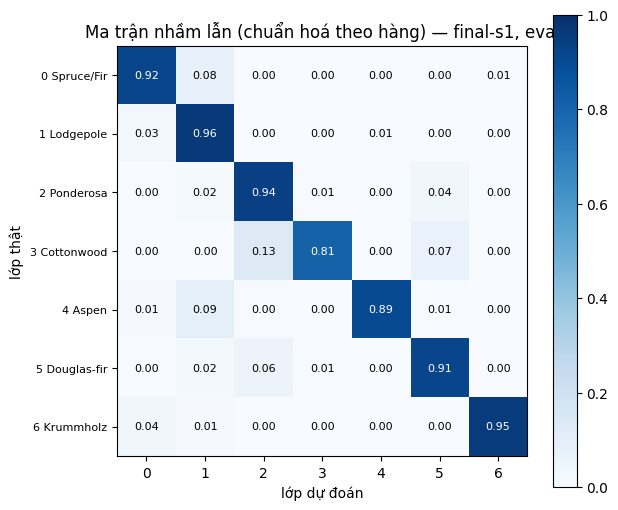

In [19]:
# 4) Phân tích lỗi theo lớp trên eval (cấu hình nộp = final-s1): bảng precision/recall/F1 + ma trận nhầm lẫn
import matplotlib.pyplot as plt
er = EVAL[SUBMIT]
cm = np.array(er["confusion_matrix"])
NAMES = ["0 Spruce/Fir", "1 Lodgepole", "2 Ponderosa", "3 Cottonwood", "4 Aspen", "5 Douglas-fir", "6 Krummholz"]
print(f"{'lớp':16s} {'support':>8s} {'precision':>10s} {'recall':>8s} {'F1':>8s}  nhầm nhiều nhất với")
for c in range(7):
    pc = er["per_class"][c]
    off = cm[c].copy(); off[c] = 0
    top = int(off.argmax())
    print(f"{NAMES[c]:16s} {pc['support']:>8d} {pc['precision']:>10.4f} {pc['recall']:>8.4f} {pc['f1']:>8.4f}  lớp {top} ({off[top]} mẫu, {off[top] / cm[c].sum():.1%} support)")
print("\nma trận nhầm lẫn (hàng = thật, cột = dự đoán):")
print(pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"dự đoán {c}" for c in range(7)]).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5.5))
norm = cm / cm.sum(1, keepdims=True)
im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{norm[i, j]:.2f}", ha="center", va="center", color="white" if norm[i, j] > 0.5 else "black", fontsize=8)
ax.set_xticks(range(7)); ax.set_yticks(range(7)); ax.set_xticklabels(range(7)); ax.set_yticklabels(NAMES, fontsize=8)
ax.set_xlabel("lớp dự đoán"); ax.set_ylabel("lớp thật"); ax.set_title(f"Ma trận nhầm lẫn (chuẩn hoá theo hàng) — {SUBMIT}, eval")
fig.colorbar(im, ax=ax); fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figures/confusion_final.png", dpi=110); plt.show()

**Phân tích lỗi (cấu hình nộp `final-s1`, eval; số lấy từ `eval_result.json`):** macro-F1 = **0.9065**, accuracy = 0.9402. **Lớp khó nhất** theo F1 là **lớp 3 (Cottonwood/Willow, F1 = 0.834)**, kế đó là **lớp 4 (Aspen, F1 = 0.838)**. Lớp 3 chỉ có 549 mẫu eval (0.47%) nên chỉ cần vài chục lỗi đã kéo recall xuống 0.807; nó chủ yếu bị nhầm sang **lớp 2 (Ponderosa, 69 mẫu = 12.6% support)** và lớp 5 (37 mẫu), (giả thuyết chưa kiểm chứng: hai loại này có phân bố độ cao, khoảng cách tới nguồn nước và loại đất chồng lấn nhau). Lớp 4 có recall cao (0.895) nhưng **precision thấp nhất (0.787)**: mô hình đoán lớp 4 hơi "rộng tay": 370 mẫu thật là lớp 1 (Lodgepole) bị đoán thành lớp 4 (nguồn chính của dương tính giả), còn 164 mẫu lớp 4 bị đoán thành lớp 1; có thể do Aspen và Lodgepole chồng lấn đặc trưng (chưa kiểm chứng). Hai lớp lớn **0 (Spruce/Fir) và 1 (Lodgepole) nhầm nhau nhiều nhất về số lượng tuyệt đối** (3 230 mẫu lớp 0 → 1 và 1 602 mẫu lớp 1 → 0), có thể vì phân bố đặc trưng của hai lớp chồng lấn; nhưng do support rất lớn (42 368 và 56 661) nên F1 vẫn cao (0.936 và 0.949). Điểm chung: các lỗi tập trung ở các cặp lớp có điều kiện sinh thái giống nhau, và macro-F1 bị lớp hiếm kéo xuống nhiều hơn accuracy (0.9065 so với 0.9402). **Lý giải bằng dữ liệu** là số mẫu ít (lớp 3, 4) và đặc trưng chồng lấn; **chưa kiểm chứng** bằng thí nghiệm cụ thể. **Cách cải thiện mình sẽ thử:** trọng số lớp hoặc lấy mẫu lại cho lớp 3 và 4 (class-weighted CE), huấn luyện lâu hơn (best epoch là 40 ở 3 trong 5 seed, nên chưa hội tụ hẳn), và mạng rộng hơn.

In [20]:
# 5) Bảng experiments.xlsx từ results/*.json (điền eval_acc/eval_macro_f1 chỉ cho baseline và cấu hình cuối cùng)
GROUP_ORDER = ["baseline", "loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init", "other", "final"]
results = load_results(f"{OUT_DIR}/results")
results.sort(key=lambda r: (GROUP_ORDER.index(r["cfg"]["group"]), r["cfg"]["exp_id"]))
rows = [to_row(r, eval_scores=EVAL.get(r["cfg"]["exp_id"])) for r in results]
SUMMARY_NOTES = {'baseline': '5 seed, lr=0.3 chọn bằng val: val macro-F1 0.8577 ± 0.0029 (2σ = 0.0058). Chưa quá khớp, best epoch ≈ 20.', 'loss': 'MSE kém CE rõ (0.782 / 0.628 so với ~0.858, vượt 2σ): gradient MSE nhỏ hơn ~7 lần; tăng lr cho MSE không giúp.', 'optimizer': 'Adam lr 3e-3 tốt nhất (0.8727, vượt 2σ so với SGD+momentum 0.8551); AdamW(wd=0) trùng Adam tuyệt đối; SGD thuần kém nhất.', 'hparam': 'lr 0.3 gần ngưỡng sập (1.0 sập); batch 128 cùng lr kém, batch 2048 kém, M-wide +0.020, M-deep không đổi, wd 5e-4 làm xấu, 40 epoch +0.023.', 'dropout': 'Dropout làm xấu đơn điệu theo q (0.835 / 0.768 / 0.631): mô hình chưa quá khớp.', 'clipping': 'c=0.35 cải thiện nhẹ ở lr 0.3 (+0.0076, sát 2σ), cứu được lr 1.0 (0.817) nhưng không cứu được lr 3.0.', 'amp': 'FP16/BF16 không nhanh hơn trên MPS (1.34 / 1.08 so với 0.93 s/epoch); độ chính xác không đổi trong nhiễu.', 'init': 'zeros hỏng (= đoán lớp đa số); normal, xavier, default học tốt, He không vượt; lr đã chọn riêng cho He nên có confound.', 'final': 'Cấu hình cuối cùng chọn bằng val từ cand-*, 5 seed (final-s1..5); điểm eval trong cột eval_*; xem REPORT.md mục 4.', 'other': 'Các ứng viên cand-* dùng để chọn cấu hình cuối cùng bằng val (seed 1); không có điểm eval.'}
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=base_ids, summary_notes=SUMMARY_NOTES)

# kiểm tra: mỗi dòng có đúng một ảnh, tên trùng exp_id
import openpyxl
wb = openpyxl.load_workbook(f"{OUT_DIR}/experiments.xlsx")
ws = wb["Experiments"]
ids = [ws.cell(r, 1).value for r in range(2, 62) if ws.cell(r, 1).value]
missing = [i for i in ids if not os.path.exists(f"{OUT_DIR}/figures/{i}.png")]
print(f"{len(ids)} dòng trong bảng | ảnh figures/<exp_id>.png thiếu: {missing}")
assert len(ids) == len(set(ids)) == len(rows) and not missing
print("nhóm:", {g: sum(1 for r in rows if r["group"] == g) for g in GROUP_ORDER})
print("ảnh chồng:", sorted(f for f in os.listdir(f"{OUT_DIR}/figures") if not f.startswith(("base-", "hp-", "loss-", "opt-", "drop-", "clip-", "amp-", "init-", "final-"))))

50 dòng trong bảng | ảnh figures/<exp_id>.png thiếu: []
nhóm: {'baseline': 5, 'loss': 2, 'optimizer': 10, 'hparam': 12, 'dropout': 3, 'clipping': 4, 'amp': 2, 'init': 4, 'other': 3, 'final': 5}
ảnh chồng: ['cand-adam-ep40.png', 'cand-adam-wide-ep40.png', 'cand-adam-wide.png', 'compare_amp.png', 'compare_clipping.png', 'compare_clipping_gradnorm.png', 'compare_dropout.png', 'compare_final.png', 'compare_hparam.png', 'compare_hparam_batch.png', 'compare_init.png', 'compare_loss.png', 'compare_loss_gradnorm.png', 'compare_optimizer.png', 'compare_optimizer_adam_lr.png', 'compare_optimizer_valloss.png', 'confusion_final.png', 'overfit20.png']
